# Baseline: TF-IDF + Logistic Regression
Notebook ini membangun model klasifikasi Stance tradisional sebagai acuan performa (baseline).

In [1]:
# Environment Configuration & Setup
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle
import torch
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

ENVIRONMENT = "local" # or "kaggle"

if ENVIRONMENT == "kaggle":
    TRAIN_PATH = "/kaggle/input/datasets/deanfebrio/aol-textmining-fakenewsdetection-dataset/processed/train_processed.csv"
    TEST_PATH = "/kaggle/input/datasets/deanfebrio/aol-textmining-fakenewsdetection-dataset/processed/test_processed.csv"
    OUTPUT_DIR = "/kaggle/working/model-baseline/"
elif ENVIRONMENT == "local":
    TRAIN_PATH = "./data/processed/train_processed.csv"
    TEST_PATH = "./data/processed/test_processed.csv"
    OUTPUT_DIR = "./artifacts/model-baseline/"
else:
    raise ValueError(f"Unknown environment: {ENVIRONMENT}")

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Environment: {ENVIRONMENT}")
print(f"Train path: {TRAIN_PATH}")
print(f"Test path: {TEST_PATH}")
print(f"Output dir: {OUTPUT_DIR}")


Environment: local
Train path: ./data/processed/train_processed.csv
Test path: ./data/processed/test_processed.csv
Output dir: ./artifacts/model-baseline/


## Load Data & Group Split
Membagi dataset training dengan metode `GroupShuffleSplit` untuk memisahkan Validation Set berdasarkan `Body ID`.

In [2]:
# Load Data
print("Loading datasets...")
df_train_full = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)

print("Full Train Shape:", df_train_full.shape)
print("Test Shape:", df_test.shape)
print("\nLabel Distribution (Train):\n", df_train_full['Stance'].value_counts())
print("\nUnique Body IDs (Train):", df_train_full['Body ID'].nunique())

# Critical Requirement: Group Split by Body ID
# Mencegah overlap Body ID antara train dan validation (mencegah data leakage)
print("\nPerforming GroupShuffleSplit...")
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Get the indices for train and validation
train_idx, val_idx = next(gss.split(df_train_full, groups=df_train_full['Body ID']))

df_train = df_train_full.iloc[train_idx].copy()
df_val = df_train_full.iloc[val_idx].copy()

print("Train Shape:", df_train.shape)
print("Val Shape:", df_val.shape)
print("Unique Body IDs (Train):", df_train['Body ID'].nunique())
print("Unique Body IDs (Val):", df_val['Body ID'].nunique())

# Explicitly check for overlap
train_bodies = set(df_train['Body ID'].unique())
val_bodies = set(df_val['Body ID'].unique())
overlap = train_bodies.intersection(val_bodies)
print(f"Overlap Body IDs between Train and Val: {len(overlap)}")
assert len(overlap) == 0, "DATA LEAKAGE DETECTED! Body IDs overlap."


Loading datasets...
Full Train Shape: (49972, 4)
Test Shape: (25413, 3)

Label Distribution (Train):
 Stance
unrelated    36545
discuss       8909
agree         3678
disagree       840
Name: count, dtype: int64

Unique Body IDs (Train): 1683

Performing GroupShuffleSplit...
Train Shape: (39587, 4)
Val Shape: (10385, 4)
Unique Body IDs (Train): 1346
Unique Body IDs (Val): 337
Overlap Body IDs between Train and Val: 0


## Label Encoding
Mengonversi kelas `Stance` menjadi angka dengan `LabelEncoder` dan menyimpan mapping kelasnya.

In [3]:
# Label Encoding
print("Encoding labels...")
le = LabelEncoder()

# Fit on train and transform
df_train['label'] = le.fit_transform(df_train['Stance'])
df_val['label'] = le.transform(df_val['Stance'])
if 'Stance' in df_test.columns:
    df_test['label'] = le.transform(df_test['Stance'])

# Mapping
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label Mapping:", label_mapping)

# Save encoder
encoder_path = os.path.join(OUTPUT_DIR, 'label_encoder.pkl')
with open(encoder_path, 'wb') as f:
    pickle.dump(le, f)
print(f"Label encoder saved to {encoder_path}")


Encoding labels...
Label Mapping: {'agree': np.int64(0), 'disagree': np.int64(1), 'discuss': np.int64(2), 'unrelated': np.int64(3)}
Label encoder saved to ./artifacts/model-baseline/label_encoder.pkl


## Evaluation & Utility Functions
Fungsi-fungsi seragam yang diimplementasikan di semua notebook untuk mengkalkulasi matriks F1, menampilkan heatmap, dan mengekstrak *top error analysis*.

In [4]:
# Common Evaluation Functions
# F1 Macro digunakan sebagai metrik utama karena class imbalance.

def evaluate_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    
    return {
        'accuracy': acc,
        'precision_macro': prec_macro,
        'recall_macro': rec_macro,
        'f1_macro': f1_macro,
        'precision_weighted': prec_weighted,
        'recall_weighted': rec_weighted,
        'f1_weighted': f1_weighted
    }

def plot_confusion_matrix(y_true, y_pred, classes, output_dir):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'confusion_matrix.png'))
    plt.show()

def get_error_analysis(df, y_true, y_pred, probs, classes, top_n=20):
    errors = []
    for i in range(len(y_true)):
        if y_true[i] != y_pred[i]:
            confidence = np.max(probs[i])
            errors.append({
                'Body ID': df.iloc[i].get('Body ID', ''),
                'Headline': df.iloc[i].get('Headline', ''),
                'Article Body': df.iloc[i].get('articleBody', '')[:200] + "...",
                'True Label': classes[y_true[i]],
                'Predicted Label': classes[y_pred[i]],
                'Confidence': confidence
            })
    
    df_errors = pd.DataFrame(errors)
    if not df_errors.empty:
        df_errors = df_errors.sort_values(by='Confidence', ascending=False).head(top_n)
    return df_errors


## Text Formatting
Menggabungkan `Headline` dan `Article Body` secara literal dengan token pemisah `[SEP]` agar fitur *unigram/bigram* bisa terbentuk.

In [5]:
# Text Format (TF-IDF)
print("Formatting text...")
# Menggunakan hasil preprocessing secara langsung tanpa membuang stopword, stemming, dll.
df_train['combined_text'] = df_train['Headline'] + " [SEP] " + df_train['articleBody']
df_val['combined_text'] = df_val['Headline'] + " [SEP] " + df_val['articleBody']
if 'Headline' in df_test.columns and 'articleBody' in df_test.columns:
    df_test['combined_text'] = df_test['Headline'] + " [SEP] " + df_test['articleBody']


Formatting text...


## TF-IDF Vectorization
Mentransformasi teks menjadi vektor statistik.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

print("Extracting TF-IDF features...")
vectorizer = TfidfVectorizer(
    lowercase=False,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True,
    max_features=50000
)

X_train = vectorizer.fit_transform(df_train['combined_text'])
X_val = vectorizer.transform(df_val['combined_text'])
if 'combined_text' in df_test.columns:
    X_test = vectorizer.transform(df_test['combined_text'])
    
y_train = df_train['label'].values
y_val = df_val['label'].values

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)


Extracting TF-IDF features...
X_train shape: (39587, 50000)
X_val shape: (10385, 50000)


## Modeling (Logistic Regression)
Model Baseline menggunakan *Logistic Regression*.

In [7]:
from sklearn.linear_model import LogisticRegression

print("Training Logistic Regression Model...")
# Param class_weight="balanced" akan sangat krusial dalam mengatasi imbalance FNC-1
model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print("Training complete!")


Training Logistic Regression Model...
Training complete!


## Evaluation & Error Analysis
Evaluasi komprehensif, menampilkan *Confusion Matrix*, *F1 Macro*, dan mengurutkan 20 prediksi salah dengan *confidence* tertinggi.

Evaluating on Validation Set...

Validation Metrics:
accuracy: 0.3508
precision_macro: 0.3450
recall_macro: 0.5130
f1_macro: 0.3073
precision_weighted: 0.6762
recall_weighted: 0.3508
f1_weighted: 0.3725

Classification Report:
              precision    recall  f1-score   support

       agree       0.15      0.55      0.24       774
    disagree       0.15      0.56      0.23       174
     discuss       0.25      0.69      0.36      1650
   unrelated       0.83      0.26      0.39      7787

    accuracy                           0.35     10385
   macro avg       0.35      0.51      0.31     10385
weighted avg       0.68      0.35      0.37     10385



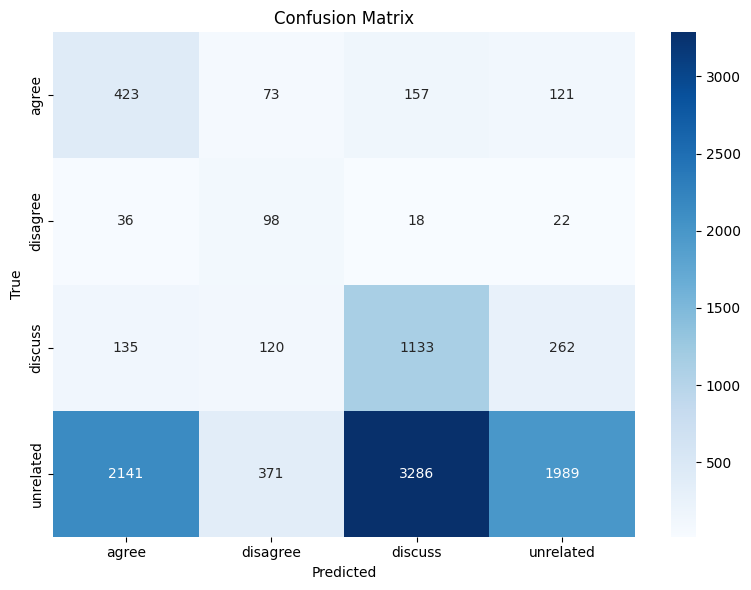


Top 20 Error Analysis (Highest Confidence):


,Body ID,Headline,Article Body,True Label,Predicted Label,Confidence
6589,2524,Rep. Duncan Hunter: 'At Least 10' ISIS Fighter...,President Obama said Wednesday that the United...,unrelated,discuss,0.945964
4198,1642,Durex Is Not Making Pumpkin Spice Condoms Afte...,The Scottish SPCA is appealing to the public f...,unrelated,agree,0.939765
4216,1642,What was fake on the Internet this week: Obama...,The Scottish SPCA is appealing to the public f...,unrelated,agree,0.932127
3846,1530,James Foley Killer ‘Jihadi John’ Believed to B...,British and US intelligence have identified Br...,discuss,unrelated,0.930153
6592,2524,Islamic State Declares Captured Aid Worker to ...,President Obama said Wednesday that the United...,unrelated,discuss,0.929399
6617,2524,Video shows ISIL beheading of photojournalist ...,President Obama said Wednesday that the United...,agree,discuss,0.928031
6605,2524,Guantanamo Detainee Exchanged for American POW...,President Obama said Wednesday that the United...,unrelated,discuss,0.927160
6593,2524,Obama denounces killing of journalist James Fo...,President Obama said Wednesday that the United...,agree,discuss,0.926918
6619,2524,Video showing American journalist beheaded bel...,President Obama said Wednesday that the United...,agree,discuss,0.926830
6611,2524,Bergdahl: Senator Says Jihadists Swapped For U...,President Obama said Wednesday that the United...,unrelated,discuss,0.926572


In [8]:
# Predict and Evaluate on Validation Set
print("Evaluating on Validation Set...")
preds = model.predict(X_val)
probs = model.predict_proba(X_val)

metrics = evaluate_metrics(y_val, preds)
print("\nValidation Metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

# Save metrics
metrics_path = os.path.join(OUTPUT_DIR, 'metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=4)

# Classification Report
target_names = [str(c) for c in le.classes_]
print("\nClassification Report:")
report = classification_report(y_val, preds, target_names=target_names)
print(report)

# Save Classification Report
df_report = pd.DataFrame(classification_report(y_val, preds, target_names=target_names, output_dict=True)).transpose()
df_report.to_csv(os.path.join(OUTPUT_DIR, 'classification_report.csv'))

# Plot and save Confusion Matrix
plot_confusion_matrix(y_val, preds, target_names, OUTPUT_DIR)

# Error Analysis
print("\nTop 20 Error Analysis (Highest Confidence):")
df_errors = get_error_analysis(df_val, y_val, preds, probs, le.classes_, top_n=20)
display(df_errors)

# Save predictions
df_val_preds = df_val.copy()
df_val_preds['predicted_label'] = preds
df_val_preds['confidence'] = np.max(probs, axis=1)
df_val_preds.to_csv(os.path.join(OUTPUT_DIR, 'predictions_validation.csv'), index=False)


## Save Artifacts
Menyimpan model baseline beserta ekstrator parameternya.

In [9]:
# Save Models
print("Saving models...")
vectorizer_path = os.path.join(OUTPUT_DIR, 'tfidf_vectorizer.pkl')
model_path = os.path.join(OUTPUT_DIR, 'logistic_regression.pkl')

with open(vectorizer_path, 'wb') as f:
    pickle.dump(vectorizer, f)
with open(model_path, 'wb') as f:
    pickle.dump(model, f)

print(f"Vectorizer saved to {vectorizer_path}")
print(f"Model saved to {model_path}")


Saving models...
Vectorizer saved to ./artifacts/model-baseline/tfidf_vectorizer.pkl
Model saved to ./artifacts/model-baseline/logistic_regression.pkl
